In [5]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

filename = next(iter(uploaded))
df=pd.read_csv(io.BytesIO(uploaded[filename]),encoding="cp1252")

print("Uploaded and loaded:",filename)
print("Datset Shape:",df.shape)
display(df.head())

Saving Articles.csv to Articles.csv
Uploaded and loaded: Articles.csv
Datset Shape: (2692, 4)


,Article,Date,Heading,NewsType
0,KARACHI: The Sindh government has decided to b...,1/1/2015,sindh govt decides to cut public transport far...,business
1,HONG KONG: Asian markets started 2015 on an up...,1/2/2015,asia stocks up in new year trad,business
2,HONG KONG: Hong Kong shares opened 0.66 perce...,1/5/2015,hong kong stocks open 0.66 percent lower,business
3,HONG KONG: Asian markets tumbled Tuesday follo...,1/6/2015,asian stocks sink euro near nine year,business
4,NEW YORK: US oil prices Monday slipped below $...,1/6/2015,us oil prices slip below 50 a barr,business


In [7]:
#Dataset size and column names
print("Dataset Shape:",df.shape)
print("Column Names:",df.columns.tolist())

#Column data types and non-null counts
print("\nDataset Information:")
df.info()

#Preview the data
display(df.head())

#Check missing and blank values
print("\nBlank Values:")
print(df.apply(lambda column: column.astype(str).str.strip().eq("").sum()))

#Check Duplicates
print("\nDuplicate rows:",df.duplicated().sum())
print("Duplicate Article texts:",df["Article"].duplicated().sum())

#Check News categories
print("\nNews Categories:")
print(df["NewsType"].value_counts())

#Understand Article lengths
word_counts=df["Article"].fillna("").str.split().str.len()
print("\nArticle Length Summary (words)")
print(word_counts.describe().round(1))

#Read One complete article
print("\nSample Article:")
print(df["Article"].iloc[0])

Dataset Shape: (2692, 4)
Column Names: ['Article', 'Date', 'Heading', 'NewsType']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2692 entries, 0 to 2691
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Article   2692 non-null   object
 1   Date      2692 non-null   object
 2   Heading   2692 non-null   object
 3   NewsType  2692 non-null   object
dtypes: object(4)
memory usage: 84.3+ KB


,Article,Date,Heading,NewsType
0,KARACHI: The Sindh government has decided to b...,1/1/2015,sindh govt decides to cut public transport far...,business
1,HONG KONG: Asian markets started 2015 on an up...,1/2/2015,asia stocks up in new year trad,business
2,HONG KONG: Hong Kong shares opened 0.66 perce...,1/5/2015,hong kong stocks open 0.66 percent lower,business
3,HONG KONG: Asian markets tumbled Tuesday follo...,1/6/2015,asian stocks sink euro near nine year,business
4,NEW YORK: US oil prices Monday slipped below $...,1/6/2015,us oil prices slip below 50 a barr,business



Blank Values:
Article     0
Date        0
Heading     0
NewsType    0
dtype: int64

Duplicate rows: 107
Duplicate Article texts: 108

News Categories:
NewsType
sports      1408
business    1284
Name: count, dtype: int64

Article Length Summary (words)
count    2692.0
mean      291.3
std       173.8
min        32.0
25%       166.0
50%       263.5
75%       381.0
max      3051.0
Name: Article, dtype: float64

Sample Article:
KARACHI: The Sindh government has decided to bring down public transport fares by 7 per cent due to massive reduction in petroleum product prices by the federal government, Geo News reported.Sources said reduction in fares will be applicable on public transport, rickshaw, taxi and other means of traveling.Meanwhile, Karachi Transport Ittehad (KTI) has refused to abide by the government decision.KTI President Irshad Bukhari said the commuters are charged the lowest fares in Karachi as compare to other parts of the country, adding that 80pc vehicles run on Compressed 

In [8]:
#Data Cleaning
import pandas as pd
import re
import html
import unicodedata

# 1. Create a separate copy so the original dataset stays available
df_clean = df.copy()
original_rows = len(df_clean)

# 2. Remove rows with missing article text
df_clean = df_clean.dropna(subset=["Article"]).copy()

# 3. Define a function to clean each article
def clean_article(text):
    text = str(text)

    # Convert HTML entities: "&amp;" becomes "&"
    text = html.unescape(text)

    # Standardise Unicode characters, such as full-width letters
    text = unicodedata.normalize("NFKC", text)

    # Standardise curly quotation marks and apostrophes
    text = text.translate(str.maketrans({
        "‘": "'",
        "’": "'",
        "“": '"',
        "”": '"'
    }))

    # Remove web addresses
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Add a space at likely joined sentence boundaries:
    # "reported.Sources" becomes "reported. Sources"
    text = re.sub(r"([a-z])([.!?])([A-Z])", r"\1\2 \3", text)

    # Treat uppercase and lowercase versions as the same word
    text = text.lower()

    # Replace repeated spaces, tabs, and line breaks with one space
    text = re.sub(r"\s+", " ", text).strip()

    return text

# 4. Store cleaned text alongside the original article
df_clean["clean_article"] = df_clean["Article"].apply(clean_article)

# 5. Remove articles that are empty after cleaning
df_clean = df_clean[df_clean["clean_article"].str.len() > 0].copy()
rows_before_deduplication = len(df_clean)

# 6. Remove repeated cleaned articles
df_clean = df_clean.drop_duplicates(subset=["clean_article"])
df_clean = df_clean.reset_index(drop=True)

# 7. Verify the cleaning results
print("Original rows:", original_rows)
print("Missing or empty articles removed:",
      original_rows - rows_before_deduplication)
print("Duplicate articles removed:",
      rows_before_deduplication - len(df_clean))
print("Remaining articles:", len(df_clean))
print("Missing cleaned articles:", df_clean["clean_article"].isna().sum())
print("Remaining duplicates:",
      df_clean["clean_article"].duplicated().sum())

# 8. Compare original and cleaned text
if not df_clean.empty:
    print("\nOriginal text:")
    print(df_clean.loc[0, "Article"][:600])

    print("\nCleaned text:")
    print(df_clean.loc[0, "clean_article"][:600])

Original rows: 2692
Missing or empty articles removed: 0
Duplicate articles removed: 108
Remaining articles: 2584
Missing cleaned articles: 0
Remaining duplicates: 0

Original text:
KARACHI: The Sindh government has decided to bring down public transport fares by 7 per cent due to massive reduction in petroleum product prices by the federal government, Geo News reported.Sources said reduction in fares will be applicable on public transport, rickshaw, taxi and other means of traveling.Meanwhile, Karachi Transport Ittehad (KTI) has refused to abide by the government decision.KTI President Irshad Bukhari said the commuters are charged the lowest fares in Karachi as compare to other parts of the country, adding that 80pc vehicles run on Compressed Natural Gas (CNG). Bukhari s

Cleaned text:
karachi: the sindh government has decided to bring down public transport fares by 7 per cent due to massive reduction in petroleum product prices by the federal government, geo news reported. sources sa

In [9]:
# Dividing the cleaned dataset
from sklearn.model_selection import train_test_split

# 1. Split into 80% training and 20% remaining
train_df, remaining_df = train_test_split(
    df_clean,
    test_size=0.20,
    random_state=42,
    stratify=df_clean["NewsType"]
)

# 2. Split the remaining portion into 10% validation and 10% test
val_df, test_df = train_test_split(
    remaining_df,
    test_size=0.50,
    random_state=42,
    stratify=remaining_df["NewsType"]
)

# 3. Reset row numbers
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# 4. Display dataset sizes
print("Training articles:", len(train_df))
print("Validation articles:", len(val_df))
print("Test articles:", len(test_df))
print("Total articles:", len(df_clean))

# 5. Check for identical articles shared across sets
train_articles = set(train_df["clean_article"])
val_articles = set(val_df["clean_article"])
test_articles = set(test_df["clean_article"])

assert train_articles.isdisjoint(val_articles), "Training/validation overlap!"
assert train_articles.isdisjoint(test_articles), "Training/test overlap!"
assert val_articles.isdisjoint(test_articles), "Validation/test overlap!"

print("\nVerified: no identical cleaned articles overlap across sets.")

Training articles: 2067
Validation articles: 258
Test articles: 259
Total articles: 2584

Verified: no identical cleaned articles overlap across sets.


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

# 1. Create the tokenizer
MAX_WORDS = 10000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# 2. Build the vocabulary using training articles only
tokenizer.fit_on_texts(train_df["clean_article"])

# 3. Convert articles into lists of word IDs
train_tokens = tokenizer.texts_to_sequences(train_df["clean_article"])
val_tokens = tokenizer.texts_to_sequences(val_df["clean_article"])
test_tokens = tokenizer.texts_to_sequences(test_df["clean_article"])

# 4. Calculate the vocabulary size needed by our model, including padding
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print("Model vocabulary size:", vocab_size)
print("\nFirst 20 vocabulary entries:")
print(list(tokenizer.word_index.items())[:20])

print("\nFirst article — first 20 token IDs:")
print(train_tokens[0][:20])

Model vocabulary size: 10000

First 20 vocabulary entries:
[('<OOV>', 1), ('the', 2), ('to', 3), ('in', 4), ('of', 5), ('a', 6), ('and', 7), ('for', 8), ('on', 9), ('at', 10), ('said', 11), ('with', 12), ('that', 13), ('was', 14), ('as', 15), ('is', 16), ('by', 17), ('from', 18), ('he', 19), ('́s', 20)]

First article — first 20 token IDs:
[1013, 2, 133, 251, 210, 23, 1158, 931, 12, 40, 52, 46, 213, 477, 3, 1, 6, 227, 1309, 2194]


In [11]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Use up to 20 previous words to predict the next word
SEQUENCE_LENGTH = 20

# 2. Create inputs and targets within each article
def create_sequences(articles, sequence_length):
    inputs = []
    targets = []

    for tokens in articles:
        for position in range(1, len(tokens)):
            start = max(0, position - sequence_length)

            inputs.append(tokens[start:position])
            targets.append(tokens[position])

    # Pad shorter inputs with zeros at the beginning
    inputs = pad_sequences(
        inputs,
        maxlen=sequence_length,
        padding="pre",
        truncating="pre",
        dtype="int32"
    )

    targets = np.asarray(targets, dtype=np.int32)

    return inputs, targets

# 3. Process the existing splits separately
X_train, y_train = create_sequences(train_tokens, SEQUENCE_LENGTH)
X_val, y_val = create_sequences(val_tokens, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_tokens, SEQUENCE_LENGTH)

# 4. Check the shapes
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# 5. Inspect one training example
print("\nInput IDs:", X_train[0])
print("Target ID:", y_train[0])

print("\nInput words:", [
    tokenizer.index_word[int(token_id)]
    for token_id in X_train[0]
    if token_id != 0
])

print("Target word:", tokenizer.index_word[int(y_train[0])])

Training: (644124, 20) (644124,)
Validation: (82151, 20) (82151,)
Test: (75487, 20) (75487,)

Input IDs: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0 1013]
Target ID: 2

Input words: ['kolkata']
Target word: the


In [12]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

# 1. Set a seed for reproducibility
tf.keras.utils.set_random_seed(42)

# 2. Build the Simple RNN model
rnn_model = Sequential([
    Input(shape=(SEQUENCE_LENGTH,), dtype="int32"),

    # Convert word IDs into learned vectors; ignore padding
    Embedding(
        input_dim=vocab_size,
        output_dim=100,
        mask_zero=True
    ),

    # Learn patterns from the sequence of word vectors
    SimpleRNN(128),

    # Predict probabilities over the vocabulary
    Dense(vocab_size, activation="softmax")
], name="simple_rnn_model")

# 3. Configure how the model will learn
rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 4. Display the model architecture and parameter counts
rnn_model.summary()

Model: "simple_rnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10000)          │     1,290,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,319,312 (8.85 MB)

 Trainable params: 2,319,312 (8.85 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import time
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Stop when validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# 2. Save the model with the lowest validation loss
checkpoint = ModelCheckpoint(
    filepath="best_rnn.keras",
    monitor="val_loss",
    save_best_only=True
)

# 3. Measure training time
start_time = time.perf_counter()

# 4. Train the Simple RNN
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=512,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

# 5. Store results for comparison with LSTM and GRU
rnn_training_seconds = time.perf_counter() - start_time

print(f"\nTraining time: {rnn_training_seconds / 60:.2f} minutes")
print(f"Epochs completed: {len(rnn_history.history['loss'])}")
print(f"Best validation loss: {min(rnn_history.history['val_loss']):.4f}")
print("Best model saved as: best_rnn.keras")

Epoch 1/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 250s 198ms/step - accuracy: 0.1309 - loss: 5.8836 - val_accuracy: 0.1484 - val_loss: 5.6484
Epoch 2/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 251s 199ms/step - accuracy: 0.1637 - loss: 5.3904 - val_accuracy: 0.1702 - val_loss: 5.3560
Epoch 3/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 263s 200ms/step - accuracy: 0.1860 - loss: 5.0911 - val_accuracy: 0.1823 - val_loss: 5.2321
Epoch 4/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 271s 207ms/step - accuracy: 0.2015 - loss: 4.8866 - val_accuracy: 0.1888 - val_loss: 5.1658
Epoch 5/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 250s 198ms/step - accuracy: 0.2129 - loss: 4.7276 - val_accuracy: 0.1933 - val_loss: 5.1342

Training time: 21.64 minutes
Epochs completed: 5
Best validation loss: 5.1342
Best model saved as: best_rnn.keras


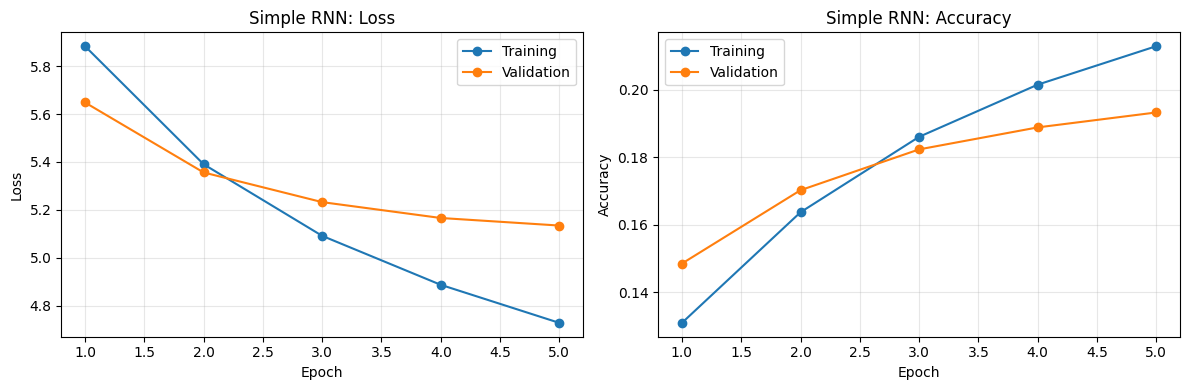

In [15]:
#Plotting RNN
import matplotlib.pyplot as plt

# 1. Get the actual number of completed epochs
epochs = range(1, len(rnn_history.history["loss"]) + 1)

# 2. Create two graphs side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3. Plot training and validation loss
axes[0].plot(
    epochs, rnn_history.history["loss"],
    marker="o", label="Training"
)
axes[0].plot(
    epochs, rnn_history.history["val_loss"],
    marker="o", label="Validation"
)
axes[0].set_title("Simple RNN: Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 4. Plot training and validation accuracy
axes[1].plot(
    epochs, rnn_history.history["accuracy"],
    marker="o", label="Training"
)
axes[1].plot(
    epochs, rnn_history.history["val_accuracy"],
    marker="o", label="Validation"
)
axes[1].set_title("Simple RNN: Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
#Build LSTM MODel
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

# 1. Set the random seed
tf.keras.utils.set_random_seed(42)

# 2. Build the LSTM model
lstm_model = Sequential([
    Input(shape=(SEQUENCE_LENGTH,), dtype="int32"),

    # Learn word representations and ignore padding
    Embedding(
        input_dim=vocab_size,
        output_dim=100,
        mask_zero=True
    ),

    # Learn sequential patterns using LSTM memory and gates
    LSTM(128),

    # Predict the next token
    Dense(vocab_size, activation="softmax")
], name="lstm_model")

# 3. Configure training
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 4. Inspect the architecture
lstm_model.summary()

Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10000)          │     1,290,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,407,248 (9.18 MB)

 Trainable params: 2,407,248 (9.18 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Move padding to the right while preserving word order
def move_padding_right(inputs):
    result = np.zeros_like(inputs)

    for row_index, row in enumerate(inputs):
        word_ids = row[row != 0]
        result[row_index, :len(word_ids)] = word_ids

    return result

X_train = move_padding_right(X_train)
X_val = move_padding_right(X_val)
X_test = move_padding_right(X_test)

print("First input after right padding:")
print(X_train[0])
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

# 2. Configure early stopping and model saving
lstm_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="best_lstm.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

# 3. Train and measure elapsed time
start_time = time.perf_counter()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=512,
    callbacks=lstm_callbacks,
    verbose=1
)

lstm_training_seconds = time.perf_counter() - start_time

# 4. Report results
print(f"\nTraining time: {lstm_training_seconds / 60:.2f} minutes")
print(f"Epochs completed: {len(lstm_history.history['loss'])}")
print(f"Best validation loss: {min(lstm_history.history['val_loss']):.4f}")
print("Best model saved as: best_lstm.keras")

First input after right padding:
[1013    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
Available GPUs: []
Epoch 1/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 420s 332ms/step - accuracy: 0.0794 - loss: 6.7154 - val_accuracy: 0.1042 - val_loss: 6.3033
Epoch 2/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 434s 326ms/step - accuracy: 0.1137 - loss: 6.1586 - val_accuracy: 0.1288 - val_loss: 5.9572
Epoch 3/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 417s 332ms/step - accuracy: 0.1343 - loss: 5.8448 - val_accuracy: 0.1444 - val_loss: 5.7439
Epoch 4/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 441s 350ms/step - accuracy: 0.1520 - loss: 5.5647 - val_accuracy: 0.1592 - val_loss: 5.5155
Epoch 5/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 441s 350ms/step - accuracy: 0.1689 - loss: 5.3096 - val_accuracy: 0.1701 - val_loss: 5.3832

Training time: 35.90 minutes
Epochs completed: 5
Best validation loss: 5.3832
Best model saved as: best_lstm.keras


In [18]:
#lets build gru model
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense

# 1. Set a seed for reproducibility
tf.keras.utils.set_random_seed(42)

# 2. Build the GRU model
gru_model = Sequential([
    Input(shape=(SEQUENCE_LENGTH,), dtype="int32"),

    # Learn word representations and ignore padding
    Embedding(
        input_dim=vocab_size,
        output_dim=100,
        mask_zero=True
    ),

    # Learn sequential patterns using GRU gates
    GRU(128),

    # Predict probabilities over the vocabulary
    Dense(vocab_size, activation="softmax")
], name="gru_model")

# 3. Configure training
gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 4. Display the architecture and parameter counts
gru_model.summary()

Model: "gru_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 20, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10000)          │     1,290,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,378,320 (9.07 MB)

 Trainable params: 2,378,320 (9.07 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import time
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Configure early stopping and best-model saving
gru_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="best_gru.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

# 2. Start measuring training time
start_time = time.perf_counter()

# 3. Train the GRU using the existing right-padded inputs
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=512,
    callbacks=gru_callbacks,
    verbose=1
)

# 4. Store training time for model comparison
gru_training_seconds = time.perf_counter() - start_time

# 5. Display the results
print(f"\nTraining time: {gru_training_seconds / 60:.2f} minutes")
print(f"Epochs completed: {len(gru_history.history['loss'])}")
print(f"Best validation loss: {min(gru_history.history['val_loss']):.4f}")
print("Best model saved as: best_gru.keras")

Epoch 1/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 395s 311ms/step - accuracy: 0.0783 - loss: 6.7729 - val_accuracy: 0.1183 - val_loss: 6.1775
Epoch 2/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 357s 284ms/step - accuracy: 0.1360 - loss: 5.8466 - val_accuracy: 0.1547 - val_loss: 5.5308
Epoch 3/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 351s 259ms/step - accuracy: 0.1698 - loss: 5.3081 - val_accuracy: 0.1751 - val_loss: 5.2867
Epoch 4/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 322s 256ms/step - accuracy: 0.1915 - loss: 5.0175 - val_accuracy: 0.1867 - val_loss: 5.1587
Epoch 5/5
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 317s 252ms/step - accuracy: 0.2066 - loss: 4.8120 - val_accuracy: 0.1935 - val_loss: 5.0854

Training time: 29.04 minutes
Epochs completed: 5
Best validation loss: 5.0854
Best model saved as: best_gru.keras


In [21]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

# These models contain the best weights restored after training
models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

def compare_predictions(input_text, top_k=5):
    # 1. Apply the same cleaning and tokenizer as training
    cleaned_text = clean_article(input_text)
    token_ids = tokenizer.texts_to_sequences([cleaned_text])[0]

    if not token_ids:
        print("Please enter a phrase containing words.")
        return

    # 2. Keep the latest words and add padding on the right
    context_ids = token_ids[-SEQUENCE_LENGTH:]

    padded_input = pad_sequences(
        [context_ids],
        maxlen=SEQUENCE_LENGTH,
        padding="post",
        truncating="pre",
        dtype="int32"
    )

    # 3. Check for unknown words in the actual input context
    oov_id = tokenizer.word_index.get(tokenizer.oov_token)
    unknown_count = sum(token_id == oov_id for token_id in context_ids)

    print("Input:", input_text)
    print("Context:", " ".join(
        tokenizer.index_word[token_id] for token_id in context_ids
    ))

    if unknown_count:
        print(f"Unknown/excluded words in context: {unknown_count}")

    # 4. Compare the top predictions from each model
    results = []

    for model_name, model in models.items():
        probabilities = model.predict(padded_input, verbose=0)[0]

        # Exclude padding and the unknown token from displayed suggestions
        valid_ids = [
            token_id
            for token_id in range(1, len(probabilities))
            if token_id != oov_id
            and token_id in tokenizer.index_word
        ]

        best_ids = sorted(
            valid_ids,
            key=lambda token_id: float(probabilities[token_id]),
            reverse=True
        )[:top_k]

        for rank, token_id in enumerate(best_ids, start=1):
            word = tokenizer.index_word[token_id]

            results.append({
                "Model": model_name,
                "Rank": rank,
                "Next word": word,
                "Probability (%)": round(
                    float(probabilities[token_id]) * 100, 2
                )
            })

    display(pd.DataFrame(results))

# 5. Enter a phrase to test all three models
manual_text = input("Enter a word or partial sentence: ")
compare_predictions(manual_text)

Enter a word or partial sentence: the company reported
Input: the company reported
Context: the company reported


,Model,Rank,Next word,Probability (%)
0,RNN,1,a,14.07
1,RNN,2,that,11.62
2,RNN,3,the,7.09
3,RNN,4,on,5.14
4,RNN,5,to,4.89
5,LSTM,1,the,13.39
6,LSTM,2,that,6.32
7,LSTM,3,on,5.58
8,LSTM,4,in,4.52
9,LSTM,5,a,4.21


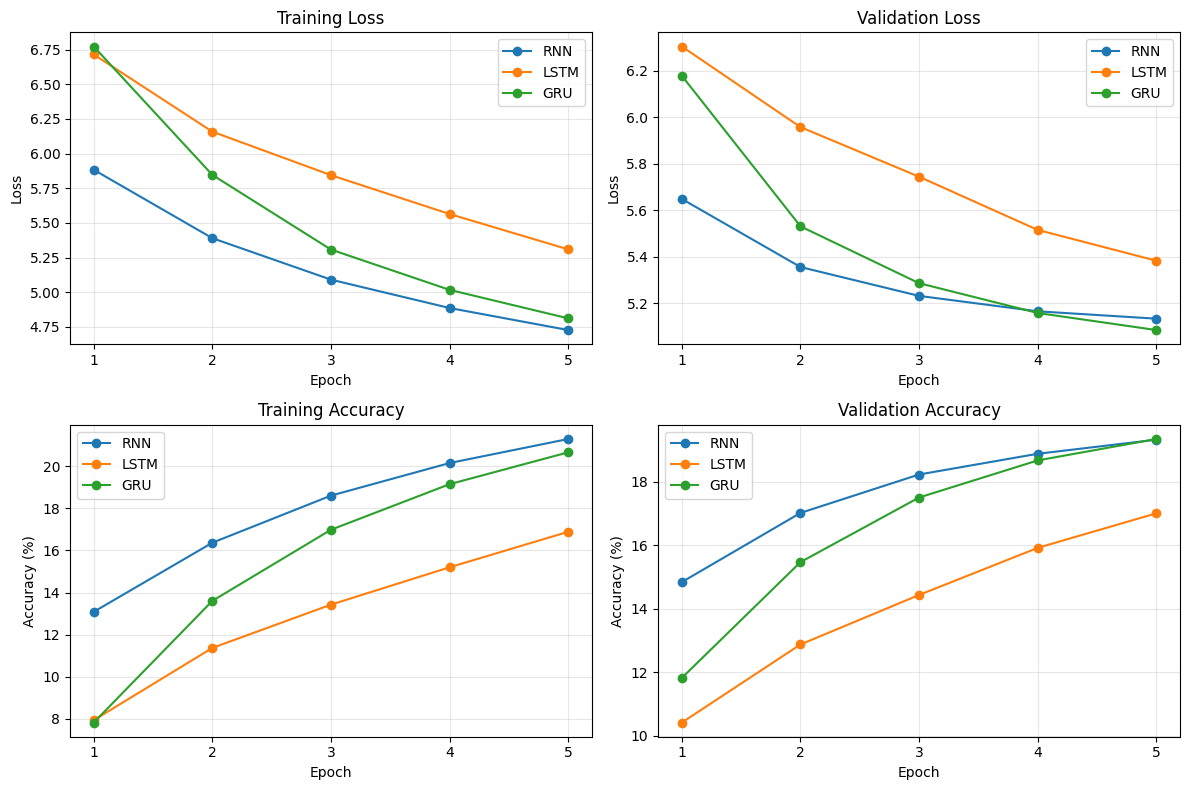

In [22]:
#Validation nCurve
import matplotlib.pyplot as plt

# 1. Collect the histories from the completed training runs
histories = {
    "RNN": rnn_history,
    "LSTM": lstm_history,
    "GRU": gru_history
}

# 2. Define the four graphs
plot_settings = [
    ("loss", "Training Loss", "Loss"),
    ("val_loss", "Validation Loss", "Loss"),
    ("accuracy", "Training Accuracy", "Accuracy (%)"),
    ("val_accuracy", "Validation Accuracy", "Accuracy (%)")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 3. Plot every model on each graph
for ax, (metric, title, ylabel) in zip(axes.flat, plot_settings):
    max_epochs = 0

    for model_name, history in histories.items():
        values = history.history[metric]
        epochs = range(1, len(values) + 1)
        max_epochs = max(max_epochs, len(values))

        # Convert accuracy from fractions to percentages
        if "accuracy" in metric:
            values = [value * 100 for value in values]

        ax.plot(epochs, values, marker="o", label=model_name)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, max_epochs + 1))
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
#EValuation
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# 1. Locate the checkpoints selected using validation loss
model_paths = {
    "RNN": "best_rnn.keras",
    "LSTM": "best_lstm.keras",
    "GRU": "best_gru.keras"
}

# 2. Check test data and report unknown targets
assert len(X_test) == len(y_test), "Inputs and targets have different lengths!"
assert len(y_test) > 0, "The test set is empty!"

oov_id = tokenizer.word_index[tokenizer.oov_token]
oov_percentage = np.mean(y_test == oov_id) * 100

print(f"Test examples: {len(y_test):,}")
print(f"Unknown/excluded target tokens: {oov_percentage:.2f}%")

# 3. Evaluate each saved model
results = []

for model_name, model_path in model_paths.items():
    print(f"\nEvaluating {model_name}...")

    model = load_model(model_path)

    metrics = model.evaluate(
        X_test,
        y_test,
        batch_size=512,
        verbose=0,
        return_dict=True
    )

    results.append({
        "Model": model_name,
        "Test loss": float(metrics["loss"]),
        "Test accuracy (%)": float(metrics["accuracy"]) * 100,
        "Test perplexity": float(np.exp(metrics["loss"])),
        "Parameters": model.count_params()
    })

    del model

# 4. Display and save the comparison
evaluation_df = pd.DataFrame(results)

display(evaluation_df.round({
    "Test loss": 4,
    "Test accuracy (%)": 2,
    "Test perplexity": 2
}))

evaluation_df.to_csv("model_evaluation.csv", index=False)
print("\nResults saved as model_evaluation.csv")

Test examples: 75,487
Unknown/excluded target tokens: 5.04%

Evaluating RNN...

Evaluating LSTM...

Evaluating GRU...


,Model,Test loss,Test accuracy (%),Test perplexity,Parameters
0,RNN,5.0615,19.91,157.83,2319312
1,LSTM,5.3284,17.30,206.11,2407248
2,GRU,5.0092,20.05,149.78,2378320



Results saved as model_evaluation.csv


What this means:
- GRU: Correctly predicts about 20 out of 100 next-token targets. Its lowest loss and perplexity indicate better probability predictions overall.
- RNN: Only 0.14 percentage points behind GRU in accuracy and had the shortest recorded training time.
- LSTM: Performed worse within our five-epoch training budget. This does not mean LSTM is always worse.
Important limitation: 5.04% of test targets are <OOV>. Predicting that placeholder counts as correct, even though it doesn’t recover the original word. These scores therefore include unknown-token prediction.
Our decision: Continue with GRU, which we already preferred based on validation loss. The test results support that choice, but the small accuracy advantage is not proof of a reliable difference across repeated runs.

In [24]:
import json
import inspect
import zipfile
import numpy as np
import pandas as pd

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from google.colab import files

# 1. Load the best GRU model
prediction_model = load_model("best_gru.keras")

# 2. Define multi-word generation
def generate_text(seed_text, num_words=10):
    if not isinstance(num_words, int) or not 1 <= num_words <= 50:
        raise ValueError("num_words must be an integer between 1 and 50.")

    # Apply the same cleaning used during training
    generated_text = clean_article(seed_text)
    initial_ids = tokenizer.texts_to_sequences([generated_text])[0]

    if not initial_ids:
        raise ValueError("Please enter a seed containing words.")

    oov_id = tokenizer.word_index[tokenizer.oov_token]

    if all(token_id == oov_id for token_id in initial_ids):
        print("Note: all seed words are outside the usable vocabulary.")

    prediction_steps = []

    for step in range(num_words):
        # Convert the growing text to IDs
        token_ids = tokenizer.texts_to_sequences([generated_text])[0]

        # Keep the latest context and pad on the right
        model_input = pad_sequences(
            [token_ids],
            maxlen=SEQUENCE_LENGTH,
            padding="post",
            truncating="pre",
            dtype="int32"
        )

        probabilities = prediction_model.predict(
            model_input, verbose=0
        )[0]

        # Exclude padding and the unknown token from suggestions
        scores = probabilities.copy()
        scores[0] = -np.inf
        scores[oov_id] = -np.inf

        next_id = int(np.argmax(scores))
        next_word = tokenizer.index_word[next_id]

        prediction_steps.append({
            "Step": step + 1,
            "Predicted word": next_word,
            "Probability (%)": round(
                float(probabilities[next_id]) * 100, 2
            )
        })

        generated_text += " " + next_word

    return generated_text, pd.DataFrame(prediction_steps)

# 3. Test generation
seed = input("Enter a word or partial sentence: ")

generated_text, prediction_details = generate_text(
    seed_text=seed,
    num_words=10
)

print("\nGenerated text:")
print(generated_text)

print("\nIndividual predictions:")
display(prediction_details)

# 4. Save the exact tokenizer
with open("tokenizer.json", "w", encoding="utf-8") as file:
    file.write(tokenizer.to_json())

# 5. Save preprocessing and generation settings
config = {
    "model_file": "best_gru.keras",
    "tokenizer_file": "tokenizer.json",
    "sequence_length": int(SEQUENCE_LENGTH),
    "vocab_size": int(prediction_model.output_shape[-1]),
    "padding": "post",
    "truncating": "pre",
    "oov_token": tokenizer.oov_token,
    "decoding": "greedy",
    "excluded_output_ids": [0, int(tokenizer.word_index[tokenizer.oov_token])],
    "tensorflow_version": __import__("tensorflow").__version__
}

with open("config.json", "w", encoding="utf-8") as file:
    json.dump(config, file, indent=2)

# 6. Save the existing cleaning function for reuse
# Run this in the same session where clean_article was defined.
cleaning_source = inspect.getsource(clean_article)

with open("preprocessing.py", "w", encoding="utf-8") as file:
    file.write("import re\nimport html\nimport unicodedata\n\n")
    file.write(cleaning_source)

# 7. Package the model and supporting files
bundle_path = "next_word_gru_bundle.zip"

with zipfile.ZipFile(
    bundle_path, "w", compression=zipfile.ZIP_DEFLATED
) as bundle:
    for filename in [
        "best_gru.keras",
        "tokenizer.json",
        "config.json",
        "preprocessing.py"
    ]:
        bundle.write(filename)

# 8. Download the bundle before ending the Colab session
files.download(bundle_path)

print("\nSaved and requested download:", bundle_path)

Enter a word or partial sentence: the company reported

Generated text:
the company reported that the government has been earmarked for the country to

Individual predictions:


,Step,Predicted word,Probability (%)
0,1,that,16.50
1,2,the,21.79
2,3,government,4.59
3,4,has,16.97
4,5,been,18.88
5,6,earmarked,3.53
6,7,for,79.99
7,8,the,34.50
8,9,country,4.77
9,10,to,13.92


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Saved and requested download: next_word_gru_bundle.zip
